# Example-09: Apply window (spectrum)

In [1]:
# Import

import numpy
import torch

import sys
sys.path.append('..')

from harmonica.window import Window

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

False
8


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

Window(4096, 'cosine_window', 2.0)


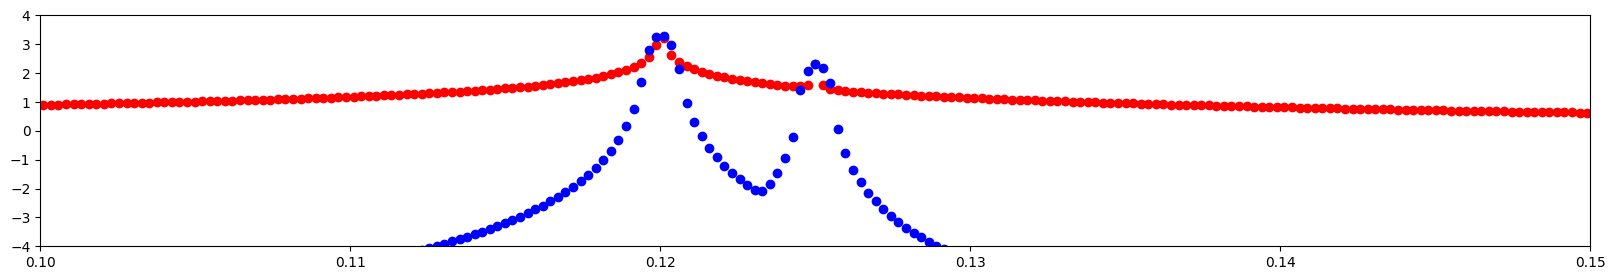

Window(4096, 'cosine_window', 4.0)
tensor(9.998263245766e-01, dtype=torch.float64)
tensor(1.000000000001e+00, dtype=torch.float64)


In [3]:
# Apply window to signal and plot DFT amplitude spectrum

# Set test signal

length = 4096

# Set test signal (two components)

signal = torch.zeros(length, dtype=dtype, device=device)
signal += 1.0*torch.sin(2.0*numpy.pi*0.120*torch.linspace(0, length, length, dtype=dtype, device=device))
signal += 0.1*torch.sin(2.0*numpy.pi*0.125*torch.linspace(0, length, length, dtype=dtype, device=device))

# Set frequency grid

grid = torch.fft.rfftfreq(length, dtype=dtype, device=device)

# Set window

w = Window.from_cosine(length, 2.0, dtype=dtype, device=device)
print(w)

# Plot

plt.figure(figsize=(20, 3))
plt.xlim(0.10, 0.15)
plt.ylim(-4, +4)
plt.scatter(grid.cpu().numpy(), torch.log10(torch.abs(torch.fft.rfft(signal))).cpu().numpy(), color='red', marker='o')
plt.scatter(grid.cpu().numpy(), torch.log10(torch.abs(torch.fft.rfft(signal*w.window))).cpu().numpy(), color='blue', marker='o'),
plt.show()

# Compute parameters with known frequency using convolution without and with window

# Set window 

w = Window.from_cosine(length, 4.0, dtype=dtype, device=device)
print(w)

# Set time

t = torch.linspace(0, length, length, dtype=dtype, device=device)

# Compute s-amplitude without and with window

print(2.0*torch.dot(signal, torch.sin(2.0*numpy.pi*0.120*t))/len(w))
print(2.0*torch.dot(signal*w.window, torch.sin(2.0*numpy.pi*0.120*t))/w.total)